# Kaggle Competition info:
## NVIDIA Nemotron Model Reasoning Challenge
#### Advance reasoning techniques using NVIDIA Nemotron open models on a novel benchmark

## Overview
Develop techniques that improve reasoning accuracy using NVIDIA Nemotron models.

Participants will experiment with prompting, data pipelines, and lightweight fine-tuning while evaluating their approaches on a new reasoning benchmark developed by NVIDIA Research.

**Link:** <https://www.kaggle.com/competitions/nvidia-nemotron-model-reasoning-challenge/overview>

## Install libary

In [1]:
# for GPU only
!nvidia-smi

Thu Jun 11 13:32:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   30C    P0             52W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
# for GPU only
!nvcc -V

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


In [3]:
# ====================== COLAB SETUP ======================
import os
from google.colab import drive

from google.colab import userdata
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

# Mount Google Drive (Recommended)
drive.mount('/content/drive')

# Create folders in Drive (persistent)
BASE_DIR = "/content/drive/MyDrive/Nemotron_Colab"
os.makedirs(f"{BASE_DIR}/data", exist_ok=True)
os.makedirs(f"{BASE_DIR}/models", exist_ok=True)
os.makedirs(f"{BASE_DIR}/outputs", exist_ok=True)
os.makedirs(f"{BASE_DIR}/mlruns", exist_ok=True)

print("✅ Google Drive mounted and folders created")

Mounted at /content/drive
✅ Google Drive mounted and folders created


In [4]:
# === Modern Unsloth Installation (from official notebook) ===
# !uv pip install  \
#     "torch==2.7.1" "triton>=3.3.0" numpy pillow torchvision bitsandbytes \
#     "transformers==5.5.0" \
#     "unsloth_zoo[base] @ git+https://github.com/unslothai/unsloth-zoo" \
#     "unsloth[base] @ git+https://github.com/unslothai/unsloth"

# !uv pip install --no-build-isolation mamba_ssm==2.2.5 causal_conv1d==1.5.2
# !uv pip install --no-deps --upgrade "torchao>=0.16.0"

%%capture
import os, importlib.util
!pip install --upgrade uv
if importlib.util.find_spec("torch") is None or "COLAB_" in "".join(os.environ.keys()):
    try: import numpy, PIL; _numpy = f"numpy=={numpy.__version__}"; _pil = f"pillow=={PIL.__version__}"
    except: _numpy = "numpy"; _pil = "pillow"
    !uv pip install  \
        "torch==2.7.1" "triton>=3.3.0" {_numpy} {_pil} torchvision bitsandbytes "transformers==4.56.2" \
        "unsloth_zoo[base] @ git+https://github.com/unslothai/unsloth-zoo" \
        "unsloth[base] @ git+https://github.com/unslothai/unsloth"
    !uv pip install  --no-deps "torchcodec==0.5"
elif importlib.util.find_spec("unsloth") is None:
    !uv pip install unsloth
!uv pip install --upgrade --no-deps transformers==4.56.2 "tokenizers>=0.22.0,<=0.23.0" trl==0.22.2 unsloth unsloth_zoo

# Mamba is supported only on torch==2.7.1. If you have newer torch versions, please wait 30 minutes!
!uv pip install --no-build-isolation mamba_ssm==2.2.5 causal_conv1d==1.5.2
!uv pip install --no-deps --upgrade "torchao>=0.16.0"

# !pip install --upgrade pip -q

# # 1. Fix pyarrow + mlflow first
# !uv pip install pyarrow==23.0.0 -q
!uv pip install mlflow==3.12.0  -q

# # 2. Core packages
# !pip install bitsandbytes==0.48.0 trl==1.2.0 xformers==0.0.35

# # 3. Flash Attention (lighter)
# !pip install flash-attn==2.8.3 --no-build-isolation --no-cache-dir

# # 4. mamba-ssm + causal-conv1d (most problematic)
# !pip install causal-conv1d==1.6.1 --no-build-isolation --no-cache-dir
# !pip install mamba-ssm==2.3.1 --no-build-isolation --no-cache-dir

# # 5. Unsloth
# !pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
# !pip install unsloth-zoo

print("✅ Clean installation completed")
print("✅ All packages installed")

In [5]:
# !pip install posthog==7.15.0
# !pip install portalocker==3.2.0
# !pip install pyfiglet==1.0.4
# !pip install databricks-sdk==0.110.0

In [6]:
# os.environ["HF_TOKEN"]

In [7]:
# !pip install -q triton
# !pip install --no-build-isolation -q "mamba-ssm>=2.2" causal-conv1d

In [8]:
import triton
import mamba_ssm
import bitsandbytes

print(triton.__version__)
print(mamba_ssm.__version__)
print(bitsandbytes.__version__)

3.3.1
2.2.5
0.49.2


In [9]:
import os

os.environ["MAMBA_FORCE_EAGER"] = "1"
os.environ["CAUSAL_CONV1D_FORCE_EAGER"] = "1"
os.environ["TRITON_DISABLE_LINE_INFO"] = "1"
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [10]:
# !pip install pandas

In [11]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
# import deepeval
import mlflow

In [12]:
# from deepeval.metrics import GEval                     # ← Only this is needed
# from deepeval.test_case import LLMTestCase
# from deepeval import evaluate

In [13]:
# from trl import DPOTrainer, DPOConfig
# from peft import PeftModel, LoraConfig
# from datasets import load_dataset
# import torch

import os, glob, sys, subprocess, site, importlib.util, shutil, stat, types, re

import datasets
import kagglehub

import torch
# import mamba_ssm later

from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from trl import SFTTrainer, SFTConfig
from trl import GRPOConfig, GRPOTrainer
from unsloth import FastLanguageModel

import pandas as pd
import random
import gc, time

import json, zipfile

/usr/local/lib/python3.12/dist-packages/torchao/quantization/quant_api.py:1745: SyntaxWarning: invalid escape sequence '\.'
  * regex for parameter names, must start with `re:`, e.g. `re:language\.layers\..+\.q_proj.weight`.
/usr/local/lib/python3.12/dist-packages/unsloth/__init__.py:153: UserWarning: WARNING: Unsloth should be imported before [trl, transformers, peft] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from ._gpu_init import *


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [14]:
import pandas as pd
import torch
import gc
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, PeftModel
from typing import Optional, Tuple, Dict


import kagglehub
# import mamba_ssm
# from trl import GRPOConfig, GRPOTrainer

In [15]:
import numpy as np
from sklearn.metrics import f1_score, recall_score, precision_score

In [16]:
import os
from huggingface_hub import snapshot_download

class CFG:
    # Use Google Drive for persistence
    BASE_DIR   = "/content/drive/MyDrive/Nemotron_Colab"
    DATA_DIR   = os.path.join(BASE_DIR, "data")
    MODEL_DIR  = os.path.join(BASE_DIR, "models")
    OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")
    MLFLOW_DIR = os.path.join(BASE_DIR, "mlruns")

    os.makedirs(DATA_DIR, exist_ok=True)
    os.makedirs(MODEL_DIR, exist_ok=True)
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    trainFile = os.path.join(DATA_DIR, "train.csv")
    testFile  = os.path.join(DATA_DIR, "test.csv")
    cotFile = os.path.join(DATA_DIR,  "train_cot2.csv")

    BASE_MODEL = "nvidia/NVIDIA-Nemotron-3-Nano-30B-A3B-Base-BF16"

    USE_COT = True
    SFT = True
    GRPO = False

In [17]:
mlflow_local= True # suitable for kaggle envirorment
# OUTPUT_DIR = "./model-finetuned"
MLFLOW_EXPERIMENT = "Nemoton-Reasoning-Fine-Tuning"


if mlflow_local:
    mlflowUrl = "sqlite:///mlflow.db" # for local sqlite db (recommend)
    # mlflowUrl = "file:///mlruns" # for local file

else:
    # localhost
    mlflowUrl = "http://localhost:5000"



def setup_mlflow_run(
    experiment_name: str = "wonderland_nemotron_reasoning",
    run_name_suffix: str = "",
    train: bool = True
):
    """
    Separate MLflow setup function.
    Sets tracking URI, experiment, starts a run, and returns the active run context.
    """
    # project setup
    mlflow.set_tracking_uri(mlflowUrl)
    mlflow.set_experiment(experiment_name)

    # === CRITICAL: End any previously active run to prevent conflict ===
    try:
        mlflow.end_run()          # safely ends any lingering run
    except:
        pass                      # no active run → ignore

    run_name = f"eval_{run_name_suffix}"
    run = mlflow.start_run(run_name=run_name)
    print(f"MLflow run started: {run_name} (ID: {run.info.run_id})")
    return run

    if train:
        run_name = f"train_{run_name_suffix}"
    else:
        run_name = f"eval_{run_name_suffix}"
    run = mlflow.start_run(run_name=run_name)
    print(f"MLflow run started: {run_name} (ID: {run.info.run_id})")
    return run




In [18]:
def clearMemory():
    for _ in range(5):
        torch.cuda.empty_cache()
        gc.collect()
        time.sleep(0.3)

In [19]:
clearMemory()

## Load Dataset

In [20]:
# ====================== DATASET LOADING ======================
def load_train_data() -> pd.DataFrame:
    """Load the full training dataset (train.csv)"""
    if CFG.USE_COT:
        df = pd.read_csv(CFG.cotFile)

        # === Filter only rows with valid CoT reasoning ===
        df = df[df["cot_reasoning"].notna() & (df["cot_reasoning"].str.strip() != "")]
        # Keep only examples where CoT is reasonable length
        # df = df[df['cot_reasoning'].str.len() < 2800]
        # === Keep only HIGH-QUALITY SHORT CoT ===
        df = df[df['cot_reasoning'].str.len() < 1600]                    # Short CoT only
        df = df[~df['cot_reasoning'].str.contains("Unable to generate|Failed after|Error", case=False)]
        df = df.reset_index(drop=True)
        # print(f"Total rows after filtering: {len(df)}")
        print(f"Total high-quality short CoT examples: {len(df)}")

    else:
        df = pd.read_csv(CFG.trainFile)
    print(f"✅ Loaded train dataset: {len(df):,} examples")
    return df


def load_val_data(val_size: int = 400) -> pd.DataFrame:
    """Load a fixed validation split from train.csv (same samples every run)"""
    train_df = load_train_data()
    if val_size > len(train_df):
        print(f"⚠️  Requested val_size ({val_size}) > available data. Using all {len(train_df)} samples.")
        val_size = len(train_df)
    val_df = train_df.sample(n=val_size, random_state=42).reset_index(drop=True)
    print(f"✅ Created fixed validation split: {len(val_df)} examples")
    return  train_df , val_df


def load_test_data() -> pd.DataFrame:
    """Load the official test dataset (test.csv) for final inference"""
    df = pd.read_csv(CFG.testFile)
    print(f"✅ Loaded test dataset: {len(df)} examples")
    return df

In [21]:
trainDF, valDF = load_val_data(200)


Total high-quality short CoT examples: 929
✅ Loaded train dataset: 929 examples
✅ Created fixed validation split: 200 examples


In [22]:
# trainDF = pd.read_csv(CFG.trainFile)
# print(f"Train samples: {len(trainDF)}")

In [23]:
# trainDF
valDF

,id,prompt,answer,cot_reasoning
0,54d2b3b0,"In Alice's Wonderland, a secret bit manipulati...",00000000,<think>\nThe user wants me to find a hidden bi...
1,4d6ab936,"In Alice's Wonderland, a secret unit conversio...",45.90,<think>\nHere's a thinking process:\n\n1. **A...
2,0311b798,"In Alice's Wonderland, a secret bit manipulati...",00000100,<think>\nThe user wants me to find a hidden bi...
3,3071e57b,"In Alice's Wonderland, numbers are secretly co...",XXXVII,<think>\nThe user wants me to identify the hid...
4,137bb1f4,"In Alice's Wonderland, a secret unit conversio...",11.38,<think>\nThe user wants me to find a hidden tr...
...,...,...,...,...
195,026106f5,"In Alice's Wonderland, a secret set of transfo...",631,<think>\nThe user wants me to find a hidden tr...
196,08aa9210,"In Alice's Wonderland, a secret unit conversio...",60.59,<think>\nThe user wants me to explain the proc...
197,012fb81b,"In Alice's Wonderland, a secret bit manipulati...",10000100,<think>\nThe user wants me to find a hidden bi...
198,3fd7e4d6,"In Alice's Wonderland, numbers are secretly co...",XXXII,<think>\nThe user wants me to find a hidden tr...


In [24]:
testDF =  load_test_data()
testDF

✅ Loaded test dataset: 3 examples


,id,prompt
0,00066667,"In Alice's Wonderland, a secret bit manipulati..."
1,000b53cf,"In Alice's Wonderland, a secret bit manipulati..."
2,00189f6a,"In Alice's Wonderland, secret encryption rules..."


In [25]:
# print(trainDF["prompt"][0])

In [26]:
trainDF

,id,prompt,answer,cot_reasoning
0,00189f6a,"In Alice's Wonderland, secret encryption rules...",cat imagines book,<think>\nThe user wants me to explain the proc...
1,001b24c4,"In Alice's Wonderland, numbers are secretly co...",XXXVIII,<think>\nThe user wants me to identify the hid...
2,0031df9c,"In Alice's Wonderland, a secret bit manipulati...",00110100,<think>\nThe user wants me to find a hidden bi...
3,0040ff76,"In Alice's Wonderland, the gravitational const...",154.62,<think>\nThe user wants me to explain how to f...
4,005ad22a,"In Alice's Wonderland, secret encryption rules...",king chases castle,<think>\nThe user wants me to explain how to f...
...,...,...,...,...
924,65f356f9,"In Alice's Wonderland, a secret unit conversio...",50.09,<think>\nHere's a thinking process:\n\n1. **A...
925,6601aa77,"In Alice's Wonderland, a secret unit conversio...",18.34,<think>\nThe user wants me to find a hidden tr...
926,663c39b6,"In Alice's Wonderland, a secret unit conversio...",45.45,<think>\nHere's a thinking process:\n\n1. **A...
927,6689ee95,"In Alice's Wonderland, a secret bit manipulati...",10001111,<think>\nThe user wants me to find a hidden bi...


In [27]:
trainDF['cot_len'] = trainDF['cot_reasoning'].str.len()

In [28]:
trainDF.cot_len.describe()

,cot_len
count,929.000000
mean,392.896663
std,256.989220
min,154.000000
25%,210.000000
50%,324.000000
75%,464.000000
max,1597.000000


# Load Model

In [29]:
# BASE_MODEL_PATH = kagglehub.model_download("metric/nemotron-3-nano-30b-a3b-bf16/transformers/default")
# Download model to persistent storage (do this once)
# local_model_path = os.path.join(CFG.MODEL_DIR, "nemotron-3-nano-30b-base-bf16")

# if not os.path.exists(os.path.join(local_model_path, "config.json")):
#     print("Downloading Nemotron-3-Nano from Hugging Face...")
#     snapshot_download(
#         repo_id=CFG.BASE_MODEL,
#         local_dir=local_model_path,
#         local_dir_use_symlinks=False,
#         resume_download=True
#     )
#     print(f"✅ Model saved to: {local_model_path}")
# local_model_path

In [30]:
UNSLOTH_VERSION = True
MAX_SEQ_LENGTH = 4096
LOAD_IN_4BIT = False

In [31]:
if UNSLOTH_VERSION:
    def load_model(
        model_name: str,
        adapter_path: Optional[str] = None
    ) -> Tuple[AutoModelForCausalLM, AutoTokenizer]:
        print(f"Loading unsloth model: {model_name} {'+ adapter: ' + adapter_path if adapter_path else '(base)'}")
        model, tokenizer = FastLanguageModel.from_pretrained(
            model_name=model_name,
            max_seq_length=MAX_SEQ_LENGTH,
            load_in_4bit=LOAD_IN_4BIT,
            load_in_8bit=False,
            full_finetuning=False,
            trust_remote_code=True,
            unsloth_force_compile=False,
            attn_implementation="eager",
            # attn_implementation= "flash_attention_2", # Memotron not support
            dtype=torch.bfloat16,
        )

        model = FastLanguageModel.get_peft_model(
            model,
            r=16,
            lora_alpha=32,
            target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
            lora_dropout= 0.0, #0.05,
            bias="none",
            use_gradient_checkpointing="unsloth", #"unsloth",   # Best for memory + stability
            random_state=42,
        )
        model.print_trainable_parameters()
        return model, tokenizer

else:
    def load_model(
        model_name: str,
        adapter_path: Optional[str] = None
    ) -> Tuple[AutoModelForCausalLM, AutoTokenizer]:
        """Load base model + optional LoRA adapter."""
        print(f"Loading model: {model_name} {'+ adapter: ' + adapter_path if adapter_path else '(base)'}")

        # === Model + LoRA (Mamba/MoE stable config) ===
        # bnb_config = BitsAndBytesConfig(
        #     load_in_4bit=True,                    # ← Change from 8-bit to 4-bit
        #     bnb_4bit_quant_type="nf4",            # nf4 is best for most models
        #     bnb_4bit_use_double_quant=True,       # Saves extra memory + more stable
        #     bnb_4bit_compute_dtype=torch.bfloat16,  # or torch.float16
        # )
        # === Model + LoRA (8-bit + smaller rank = stable for Mamba) ===
        # bnb_config = BitsAndBytesConfig(
        #     load_in_8bit=True,                    # ← Changed to 8-bit (more stable)
        #     # bnb_4bit_compute_dtype=torch.bfloat16,
        #     bnb_4bit_compute_dtype=torch.float16,
        # )

        model = AutoModelForCausalLM.from_pretrained(
            model_name,
            # quantization_config=bnb_config,
            device_map="auto",
            trust_remote_code=True,
            dtype=torch.bfloat16,
            # dtype=torch.float16 # for 8bit
        )

        if adapter_path:
            model = PeftModel.from_pretrained(model, adapter_path)

        tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token

        print("LoRA Configure")
        lora_config = LoraConfig(
            r=16,
            lora_alpha=32,
            target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
            lora_dropout=0.05,
            bias="none",
            task_type="CAUSAL_LM")
        model = get_peft_model(model, lora_config)
        model.print_trainable_parameters()

        return model, tokenizer

## Load base model

In [32]:

# del model
# del tokenizer

In [33]:
clearMemory()

In [34]:
CFG.BASE_MODEL

'nvidia/NVIDIA-Nemotron-3-Nano-30B-A3B-Base-BF16'

In [35]:
if CFG.SFT:
    # model, tokenizer = load_model(local_model_path, None)
    model, tokenizer = load_model(CFG.BASE_MODEL, None)

Loading unsloth model: nvidia/NVIDIA-Nemotron-3-Nano-30B-A3B-Base-BF16 (base)


A new version of the following files was downloaded from https://huggingface.co/nvidia/NVIDIA-Nemotron-3-Nano-30B-A3B-Base-BF16:
- configuration_nemotron_h.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


Unsloth: WARNING `trust_remote_code` is True.
Are you certain you want to do remote code execution?
==((====))==  Unsloth 2026.6.2: Fast Nemotron_H patching. Transformers: 4.56.2.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.7.1+cu126. CUDA: 8.0. CUDA Toolkit: 12.6. Triton: 3.3.1
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


modeling_nemotron_h.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/nvidia/NVIDIA-Nemotron-3-Nano-30B-A3B-Base-BF16:
- modeling_nemotron_h.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


...

generation_config.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/420 [00:00<?, ?B/s]

nvidia/NVIDIA-Nemotron-3-Nano-30B-A3B-Base-BF16 does not have a padding token! Will use pad_token = <SPECIAL_999>.
Unsloth: Detected MoE model with num_experts = 128 and target_modules = ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']. Enabling LoRA on MoE parameters: ['mlp.experts.gate_up_proj', 'mlp.experts.down_proj']
Unsloth: PEFT set target_parameters but found no matching parameters.
This is expected for MoE models - Unsloth handles MoE expert LoRA targeting separately.
trainable params: 434,659,328 || all params: 32,012,596,672 || trainable%: 1.3578


## Evaluation function

In [36]:
import re
import difflib



import re

if 0 : #CFG.USE_COT:
    def extract_final_answer(text: str) -> str:
        """
        Extract the final answer from the model's output.
        Priority order:
        1. Content inside \boxed{}
        2. Content after </think> tag (if exists)
        3. Last meaningful line (fallback)
        """
        if not text or not isinstance(text, str):
            return ""

        text = text.strip()

        # === 1. Highest priority: Extract from \boxed{} ===
        boxed_match = re.search(r'\\boxed\{(.*?)\}', text, re.DOTALL)
        if boxed_match:
            answer = boxed_match.group(1).strip()
            # Clean common artifacts
            answer = re.sub(r'\s+', ' ', answer)  # collapse multiple spaces
            return answer

        # === 2. If model used <think>, take everything after </think> ===
        if '</think>' in text:
            after_think = text.split('</think>')[-1].strip()

            # Try to find \boxed{} after thinking
            boxed_match = re.search(r'\\boxed\{(.*?)\}', after_think, re.DOTALL)
            if boxed_match:
                return boxed_match.group(1).strip()

            # Otherwise, take the last non-empty line after </think>
            lines = [line.strip() for line in after_think.split('\n') if line.strip()]
            if lines:
                return lines[-1]

        # === 3. Fallback: Take the last meaningful line ===
        lines = [line.strip() for line in text.split('\n') if line.strip()]
        if lines:
            last_line = lines[-1]

            # Remove common prefixes the model sometimes adds
            prefixes_to_remove = [
                "the answer is", "answer:", "final answer:",
                "the final answer is", "so the answer is"
            ]
            for prefix in prefixes_to_remove:
                if last_line.lower().startswith(prefix):
                    last_line = last_line[len(prefix):].strip()
                    break

            return last_line

        # Last resort
        return text.strip()

else:

    def extract_final_answer(text: str) -> str:
        """
        Robust extraction for Nemotron 3 with <think> support.
        Priority:
        1. Content inside \boxed{}
        2. Content after </think>
        3. Last meaningful line
        """
        if not text or not isinstance(text, str):
            return ""

        text = text.strip()

        # Priority 1: Extract from \boxed{}
        match = re.search(r'\\boxed\{([^}]+)\}', text)
        if match:
            return match.group(1).strip()

        # Priority 2: Extract after </think>
        if '</think>' in text:
            after_think = text.split('</think>')[-1].strip()
            # Clean special tokens
            after_think = re.sub(r'<\|im_end\|>|<\|im_start\|>|<\|im_start\|>assistant', '', after_think).strip()
            if after_think:
                return after_think

        # Priority 3: Remove thinking block and take last line
        if '<think>' in text:
            # Remove everything inside <think> ... </think>
            text = re.sub(r'<think>.*?</think>', '', text, flags=re.DOTALL)

        # Take last non-empty line
        lines = [line.strip() for line in text.split('\n') if line.strip()]
        if lines:
            # Clean common prefixes
            last_line = re.sub(r'^(output|answer|final answer)[:\s]*', '', lines[-1], flags=re.IGNORECASE)
            return last_line.strip()

        return text.strip()

In [37]:
if 0: #CFG.USE_COT:
    def is_correct(pred: str, gt: str) -> float:
        """Compare prediction with ground truth (normalized exact match)."""
        if not pred or not gt:
            return 0.0

        pred_clean = str(pred).lower().strip()
        gt_clean = str(gt).lower().strip()

        # Remove common artifacts
        for token in ["<|im_end|>", "<|im_start|>", "</s>", "\\boxed{", "}", "<think>", "</think>"]:
            pred_clean = pred_clean.replace(token, " ")
            gt_clean = gt_clean.replace(token, " ")

        pred_clean = " ".join(pred_clean.split())
        gt_clean = " ".join(gt_clean.split())

        return 1.0 if pred_clean == gt_clean else 0.0

else:

    def is_correct(pred: str, gt: str, tolerance: float = 0.01) -> float:
        pred = pred.strip().lower()
        gt = gt.strip().lower()

        if pred == gt:
            return 1.0

        # Numerical tolerance
        try:
            p = float(pred)
            g = float(gt)
            if g == 0:
                return 1.0 if abs(p) < tolerance else 0.0
            return 1.0 if abs(p - g) / abs(g) <= tolerance else 0.0
        except:
            pass

        # String similarity fallback
        similarity = difflib.SequenceMatcher(None, pred, gt).ratio()
        return 1.0 if similarity > 0.92 else 0.0

In [39]:
if 0:
    def run_evaluation(
    model,
    tokenizer,
    val_size: int = 400,
    experiment_name: str = "wonderland_nemotron_reasoning",
    run_name_suffix: str = ""
) -> Dict:

        run = setup_mlflow_run(experiment_name, run_name_suffix)
        mlflow.log_param("val_size", val_size)
        mlflow.log_param("generation_method", "CoT_prompt + greedy + extract_final_answer")

        exact_matches = []
        start_time = time.time()

        print(f"Running evaluation on {val_size} samples using CoT-style prompt...\n")

        if UNSLOTH_VERSION:
            FastLanguageModel.for_inference(model)

        for idx, row in enumerate(valDF.iterrows(), start=1):
            _, row = row
            prompt = row['prompt']
            gt = str(row['answer']).strip()

            print(f"Eval Sample: {idx}")

            # ====================== CoT-ALIGNED PROMPT ======================
            full_prompt = f"""<|system|>You are an expert at discovering hidden transformation rules in Alice's Wonderland puzzles.

First, think step by step inside <think> </think> tags.
After you finish thinking, output ONLY the final answer inside \\boxed{{}}.
Do not add any text before or after the boxed answer.</s>
<|user|>{prompt}
<|assistant|>"""

            # Tokenize
            tokenized = tokenizer(
                full_prompt,
                return_tensors="pt",
                add_special_tokens=True
            )
            input_ids = tokenized.input_ids.to(model.device)
            input_len = input_ids.shape[-1]
            attention_mask = tokenized.attention_mask.to(model.device)

            # Generate
            outputs = model.generate(
                input_ids,
                attention_mask=attention_mask,
                max_new_tokens=512,           # Increased for reasoning
                do_sample=False,
                num_beams=1,
                eos_token_id=tokenizer.eos_token_id,
                pad_token_id=tokenizer.pad_token_id,
            )

            # Decode only generated tokens
            generated_tokens = outputs[0][input_len:]
            raw_output = tokenizer.decode(generated_tokens, skip_special_tokens=False)

            # Clean special tokens
            for token in ["<|im_end|>", "<|im_start|>", "</s>", "<|assistant|>"]:
                raw_output = raw_output.replace(token, "").strip()

            # Extract final answer
            pred = extract_final_answer(raw_output)

            # Compare
            is_exact = is_correct(pred, gt)
            exact_matches.append(is_exact)

            print(f"Exact ans : {gt}")
            print(f"Pred ans  : {pred}")
            print(f"Match     : {is_exact}")
            print("-" * 50)

            if idx % 10 == 0:
                print(f"Processed {idx} samples...")

            if idx >= val_size:
                break

        # ====================== FINAL METRICS ======================
        avg_exact_match = sum(exact_matches) / len(exact_matches)
        mlflow.log_metric("exact_match", avg_exact_match)
        mlflow.log_metric("eval_time_sec", time.time() - start_time)
        mlflow.log_metric("samples_evaluated", len(exact_matches))

        print("\n" + "=" * 65)
        print(f"=== EVALUATION RESULTS (on {len(exact_matches)} samples) ===")
        print(f"Exact Match Accuracy: {avg_exact_match:.4f} "
              f"({sum(exact_matches)} / {len(exact_matches)})")
        print("=" * 65)

        mlflow.end_run()

        return {
            "exact_match": avg_exact_match,
            "samples_used": len(exact_matches)
        }
else:
    def run_evaluation(
        model,
        tokenizer,
        val_size: int = 400,
        experiment_name: str = "wonderland_nemotron_reasoning",
        run_name_suffix: str = ""
    ) -> Dict:
        run = setup_mlflow_run(experiment_name, run_name_suffix)

        mlflow.log_param("val_size", val_size)
        mlflow.log_param("generation_method", "apply_chat_template + greedy_generate")

        test_cases = []
        exact_matches = []
        start_time = time.time()

        print(f"Running evaluation on {val_size} samples using direct generate...")

        if UNSLOTH_VERSION:
            FastLanguageModel.for_inference(model)
        for idx, row in enumerate(valDF.iterrows(), start=1):
            _, row = row  # unpack
            prompt = row['prompt']
            gt = str(row['answer']).strip()

            print(f"Eval Sample: {idx}")

            full_prompt = f"""<|system|>You are an expert at discovering hidden transformation rules in Alice's Wonderland puzzles.
    Analyze the examples carefully and determine the hidden rule.
    **Output ONLY the final answer inside \\boxed{{}}.**
    Do not explain your reasoning. Do not write any text before or after the boxed answer.
    <|user|>{prompt}
    <|assistant|>"""

            # messages = [
            #     {"role": "system", "content": "You are an expert at discovering hidden transformation rules in Alice's Wonderland puzzles. Analyze the examples carefully and output ONLY the final answer."},
            #     {"role": "user", "content": prompt}
            # ]
            # messages = [
            #     {
            #         "role": "system",
            #         "content": "You are an expert at discovering hidden transformation rules in Alice's Wonderland puzzles. "
            #                    "Analyze the examples carefully, but output ONLY the final answer. "
            #                    "Do NOT explain, do NOT show reasoning, do NOT write 'the answer is', "
            #                    "do NOT add any text before or after the answer. Just output the result."
            #     },
            #     {"role": "user", "content": prompt}
            # ]

            # full_prompt = tokenizer.apply_chat_template(
            #     messages,
            #     tokenize=False,
            #     add_generation_prompt=True,
            #     # return_tensors="pt"
            #     # enable_thinking=enable_thinking
            # )

            # Tokenize as string → tensor
            tokenized = tokenizer(
                full_prompt,
                return_tensors="pt",
                add_special_tokens=True
            )

            input_ids = tokenized.input_ids.to(model.device)
            input_len = tokenized["input_ids"].shape[-1]
            attention_mask = tokenized.attention_mask.to(model.device)

            # === Generate ===
            outputs = model.generate(
                input_ids,
                attention_mask=attention_mask,
                max_new_tokens=512,
                do_sample=False,
                num_beams=1,
                eos_token_id=tokenizer.eos_token_id,
                pad_token_id=tokenizer.pad_token_id,
            )

            # === CLEAN DECODING (new) ===
            generated_tokens = outputs[0][input_len:]
            full_output = tokenizer.decode(generated_tokens, skip_special_tokens=False)

            # Extract only assistant response
            if "<|assistant|>" in full_output:
                raw_pred = full_output.split("<|assistant|>")[-1]
            else:
                raw_pred = full_output

            # Clean special tokens
            special_tokens = ["<|im_end|>", "<|im_start|>", "<|im_start|>assistant", "</s>"]
            for token in special_tokens:
                raw_pred = raw_pred.replace(token, "").strip()

            # === Use robust extraction (supports <think> and \boxed{}) ===
            pred = extract_final_answer(raw_pred)

            # pred = pred.strip()   # final clean
            print(f"Exact ans: {gt.lower().strip()}")
            print(f"Pred ans: { pred.lower().strip()}\n")


            # is_exact = 1.0 if pred.lower().strip() == gt.lower().strip() else 0.0
            # exact_matches.append(is_exact)
            # Then in the loop:
            is_exact = is_correct(pred, gt)
            exact_matches.append(is_exact)
            print(f"Matches = {is_exact}")
            print("-"*20)

            # test_case = LLMTestCase(input=prompt, actual_output=pred, expected_output=gt)
            # test_cases.append(test_case)

            if idx % 5 == 0 or idx == len(valDF):
                print(f"   Processed {idx}  samples...")

            if idx>= val_size:
                break


        # Metrics
        avg_exact_match = sum(exact_matches) / val_size
        mlflow.log_metric("exact_match", avg_exact_match)
        mlflow.log_metric("eval_time_sec", time.time() - start_time)
        mlflow.log_metric("samples_evaluated", val_size)



        print(f"\n=== EVALUATION RESULTS ===")
        # print(f"Exact Match (manual):       {avg_exact_match:.4f}")
        # print(f"DeepEval Correctness:       {results[0].score:.4f}")
        # print(f"DeepEval Rule Quality:      {results[1].score:.4f}")
        # print(f"Evaluation time:            {time.time() - start_time:.1f} seconds")
        print(f"\n=== EVALUATION RESULTS (on exactly {len(valDF)} samples) ===")
        print(f"Exact Match Accuracy: {avg_exact_match:.4f} ({int(avg_exact_match*val_size)}/{val_size})")
        mlflow.end_run()

        return {
            # "exact_match": avg_exact_match,
            # "deepeval_correctness": results[0].score,
            # "deepeval_rule_quality": results[1].score,
            "exact_match": avg_exact_match,
            "samples_used": val_size
        }




In [40]:
def evaluate_model(
    # model_name: str,
    # adapter_path: Optional[str] = None,
    model,
    tokenizer,
    val_size: int = 400,
    experiment_name: str = "wonderland_nemotron_reasoning",
    suffix= "base"
):
    """Convenience wrapper"""
    return run_evaluation(model, tokenizer, val_size, experiment_name, run_name_suffix=suffix)

## Evaluate base model

In [41]:
if CFG.SFT:
    evaluate_model(
        # model_name= BASE_MODEL_PATH,
        model,
        tokenizer,
        val_size=10
    )

2026/06/11 13:42:02 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/11 13:42:02 INFO mlflow.store.db.utils: Updating database tables
2026/06/11 13:42:04 INFO mlflow.tracking.fluent: Experiment with name 'wonderland_nemotron_reasoning' does not exist. Creating a new experiment.


MLflow run started: eval_base (ID: fbafe06729a149a89167baa1e92f7d45)
Running evaluation on 10 samples using direct generate...
Eval Sample: 1


KeyboardInterrupt: 

In [ ]:
experiments = mlflow.search_experiments()
for exp in experiments:
    print(f"Experiment ID: {exp.experiment_id}, Name: {exp.name}")

In [ ]:
# baseEvalRet = mlflow.search_runs(experiment_ids=["1"])
baseEvalRet = mlflow.search_runs(search_all_experiments=True)
baseEvalRet

# Single Test for debug

In [42]:
# testPrompt = valDF.iloc[0]["prompt"]
# testAns = valDF.iloc[0]["answer"]
# testPrompt

In [43]:

# full_prompt = f"""<|system|>You are an expert at discovering hidden transformation rules in Alice's Wonderland puzzles.
# You MUST output ONLY the final answer. Do not explain, do not show reasoning, do not write "the answer is", do not add any text before or after the answer.
# <|user|>{testPrompt}
# <|assistant|>"""
# prompt = full_prompt

In [44]:
# messages = [
#             {"role": "system", "content": "You are an expert at discovering hidden transformation rules in Alice's Wonderland puzzles. Analyze the examples carefully and output ONLY the final answer."},
#             {"role": "user", "content": testPrompt}
#         ]

# prompt = tokenizer.apply_chat_template(
#     messages,
#     tokenize=False,
#     add_generation_prompt=True,
#     # return_tensors="pt"
#     # enable_thinking=enable_thinking
# )
# prompt

In [45]:
# tokenized = tokenizer(
#     prompt,
#     return_tensors="pt",
#     add_special_tokens=True
# )
# input_ids = tokenized.input_ids.to(model.device)
# input_len = tokenized["input_ids"].shape[-1]
# attention_mask = tokenized.attention_mask.to(model.device)

In [46]:

# === Generate ===
# outputs = model.generate(
#     input_ids,
#     attention_mask=attention_mask,
#     max_new_tokens=1024,
#     do_sample=False,
#     num_beams=1,
#     eos_token_id=tokenizer.eos_token_id,
#     pad_token_id=tokenizer.pad_token_id,
# )

In [47]:
# # Decode and extract answer
# === CLEAN DECODING (new) ===
# full_output = tokenizer.decode(outputs[0][input_len:], skip_special_tokens=False)

# # Extract only assistant response
# if "<|assistant|>" in full_output:
#     pred = full_output.split("<|assistant|>")[-1]
# else:
#     pred = full_output

# # Remove common special tokens
# special_tokens = ["<|im_end|>", "<|endoftext|>", "</s>", "<|eot_id|>", "<|im_start|>"]
# for token in special_tokens:
#     pred = pred.replace(token, "").strip()

# pred = pred.strip()   # final clean

In [48]:
# full_output

In [49]:
# pred

###
### Full SFT (Supervised Fine-Tuning) script for NVIDIA Nemotron challenge.
#### Uses real train.csv + modular functions from evaluation.py
###

In [51]:
# OUTPUT_ADAPTER = "/kaggle/working/sft_final"
SFT_ADAPTER = CFG.OUTPUT_DIR + "/sft_final"
OUTPUT_ADAPTER = CFG.OUTPUT_DIR +"/grpo_final"

In [52]:
SFT_ADAPTER

'/content/drive/MyDrive/Nemotron_Colab/outputs/sft_final'

In [53]:
SYSTEM_PROMPT = """You are an expert at discovering hidden transformation rules in Alice's Wonderland puzzles.

You must follow this exact output format:
1. First, write your step-by-step reasoning inside <think> </think> tags.
2. After finishing your thinking, output ONLY the final answer using this exact format:
\\boxed{answer}

Do not write anything before the <think> tag or after the \\boxed{} answer."""

In [55]:
if CFG.USE_COT:
    def format_sft_example(row):
        prompt = row['prompt']
        answer = str(row['answer']).strip()
        cot = str(row.get('cot_reasoning', '')).strip()

        # Clean CoT
        if '<think>' in cot:
            import re
            match = re.search(r'<think>(.*?)</think>', cot, re.DOTALL)
            if match:
                cot = match.group(1).strip()

        full_text = f"""{SYSTEM_PROMPT}
    <|user|>{prompt}
    <|assistant|><think>
    {cot}
    </think>
    \\boxed{{{answer}}}"""

        # === Smart truncation: keep the end (answer + last part of reasoning) ===
        max_len = 4096
        if len(full_text) > max_len:
            full_text = full_text[-max_len:]   # Keep the last part

        return {"text": full_text}

else:
    # add enabling thinking processing
    def format_sft_example(row):
        prompt = row['prompt']
        answer = str(row['answer']).strip()

        full_text = f"""{SYSTEM_PROMPT}

    <|im_start|>user
    {prompt}<|im_end|>
    <|im_start|>assistant
    <think>
    I need to find the hidden transformation rule...
    </think>
    \\boxed{{{answer}}}<|im_end|>"""

        return {"text": full_text}

In [56]:
# === YOUR COMPUTE_METRIC FUNCTION (added here) ===
def compute_metric(eval_pred):
    logits, labels = eval_pred

    # Convert to numpy if needed
    if isinstance(logits, torch.Tensor):
        logits = logits.cpu().numpy()
    if isinstance(labels, torch.Tensor):
        labels = labels.cpu().numpy()

    # 1. Overall next-token accuracy (keep for reference)
    shift_logits = logits[..., :-1, :]
    shift_labels = labels[..., 1:]
    preds = np.argmax(shift_logits, axis=-1)
    mask = shift_labels != -100
    token_accuracy = (preds == shift_labels & mask).sum() / mask.sum() if mask.sum() > 0 else 0.0

    # 2. Last-token metrics (much more meaningful for puzzle solving)
    last_logits = logits[:, -1, :]           # shape: (batch, vocab)
    last_labels = labels[:, -1]              # shape: (batch,)

    top3_preds = np.argsort(last_logits, axis=-1)[:, -3:]
    match = (top3_preds == last_labels[:, None])
    predictions = top3_preds[:, 2]           # top-1 prediction

    last_token_acc = (predictions == last_labels).mean()

    f1score     = f1_score(last_labels, predictions, average='weighted', zero_division=1)
    recallScore = recall_score(last_labels, predictions, average='weighted', zero_division=1)
    precision   = precision_score(last_labels, predictions, average='weighted', zero_division=1)

    # MAP@3 on last token
    map3 = 0.0
    for i in range(len(last_labels)):
        if match[i, 0]:
            map3 += 1.0
        elif match[i, 1]:
            map3 += 1.0 / 2
        elif match[i, 2]:
            map3 += 1.0 / 3
    map3Score = map3 / len(last_labels)

    return {
        "accuracy": token_accuracy,           # overall next-token (for reference)
        "last_token_accuracy": last_token_acc, # ← most important
        "recall": recallScore,
        "precision": precision,
        "f1-score": f1score,
        "map_3": map3Score
    }

## Create Dataset

In [57]:
# COLS = ['text','a']
# trainDataset = Dataset.from_pandas(tempTrainDF[COLS], split="train")
dataset = Dataset.from_pandas(trainDF).map(format_sft_example, remove_columns=trainDF.columns.tolist())
dataset

Map:   0%|          | 0/929 [00:00<?, ? examples/s]

Dataset({
    features: ['text'],
    num_rows: 929
})

In [58]:
dataset = dataset.map(
    lambda x: {"row_len": [len(text) for text in x["text"]]},
    batched=True
)

Map:   0%|          | 0/929 [00:00<?, ? examples/s]

In [59]:
lengths_series = pd.Series(dataset["row_len"])
print(lengths_series.describe())

count     929.000000
mean     1114.562971
std       258.426898
min       766.000000
25%       960.000000
50%      1071.000000
75%      1175.000000
max      2272.000000
dtype: float64


In [60]:

# === CREATE SMALL EVAL SPLIT FOR DEBUGGING ===
eval_size = 100 #50 #200
# eval_dataset = dataset.shuffle(seed=42).select(range(eval_size))
# train_dataset = dataset.shuffle(seed=42).select(range(eval_size, len(dataset)))
# print(f"✅ Train samples: {len(train_dataset)} | Eval samples: {len(eval_dataset)}")



In [61]:
# dataset["train"]
dataset = dataset.train_test_split(test_size=eval_size, seed=42, shuffle=True)
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'row_len'],
        num_rows: 829
    })
    test: Dataset({
        features: ['text', 'row_len'],
        num_rows: 100
    })
})

In [62]:
# def tokenizeFunc(batch):
#     return tokenizer(batch["text"],  max_length=2048, padding='max_length', truncation=True)

In [63]:
# dataset =  dataset.map(tokenizeFunc, batched=True)
# dataset

In [64]:
print(dataset["train"]["text"][1])

You are an expert at discovering hidden transformation rules in Alice's Wonderland puzzles.

You must follow this exact output format:
1. First, write your step-by-step reasoning inside <think> </think> tags.
2. After finishing your thinking, output ONLY the final answer using this exact format:
\boxed{answer}

Do not write anything before the <think> tag or after the \boxed{} answer.
    <|user|>In Alice's Wonderland, a secret unit conversion is applied to measurements. For example:
48.2 m becomes 67.21
36.72 m becomes 51.20
29.67 m becomes 41.37
8.12 m becomes 11.32
Now, convert the following measurement: 9.24 m
    <|assistant|><think>
    Here's a thinking process:

1.  **Analyze User Input:**
   - Input measurements (in meters): 48.2, 36.72, 29.67, 8.12
   - Output values: 67.21, 51.20, 41.37, 11.32
   - Target to convert: 9.24 m
   - Given correct answer: 12.88
   - Task: Discover the hidden transformation rule step-by-step inside `
    </think>
    \boxed{12.88}


In [65]:
# === Training ===
EXPERIMENT_NAME= "wonderland_nemotron_reasoning"
run = setup_mlflow_run(EXPERIMENT_NAME, "sft_training")
mlflow.log_params({
    "max_lora_rank": 32,
    "max_tokens": 7680,
    "max_model_len": 8192,
    "temperature": 0.0,
    "top_p": 1.0,
    "eval_strategy": "steps",
    "save_strategy": "steps"
})

MLflow run started: eval_sft_training (ID: 9445f0c3ec964539bc627a3a17f59a0b)


In [66]:
# Also check a few samples
print("\n--- Train example length ---")
print(len(dataset["train"][0]['text']))
print("\n--- Val example length ---")
print(len(dataset["test"][0]['text']))


--- Train example length ---
1031

--- Val example length ---
1239


In [73]:
TOTAL_STEPS= 200 #500 #1000 #1200 #200 #1200 #1000 #200 #1000 #100
SAVE_STEPS = TOTAL_STEPS  * 3 #// 1
EVAL_STEPS = 50 #100

In [77]:
# del trainer
clearMemory()

In [78]:
from trl import SFTTrainer as OriginalSFTTrainer
if CFG.SFT: # use Supervised Fine Tuning
    torch_dtype = model.dtype
    if UNSLOTH_VERSION:
        FastLanguageModel.for_training(model)
        trainer = OriginalSFTTrainer(
            model = model,
            processing_class=tokenizer,
            train_dataset=dataset["train"],
            eval_dataset=dataset["test"],
            # compute_metrics=compute_metric,
            args = SFTConfig(
                max_length= 3072,  #4096, #8192,
                dataset_text_field = "text",
                completion_only_loss=True,  # ← Recommended for reasoning
                per_device_train_batch_size=1,
                gradient_accumulation_steps=4, #4,
                per_device_eval_batch_size=1,          # ← CRITICAL for OOM fix
                eval_accumulation_steps=8,             # ← CRITICAL for OOM fix
                warmup_steps = 20, #5,
                num_train_epochs = 1, # Set this for 1 full training run.
                max_steps=TOTAL_STEPS, # for testing
                learning_rate = 2e-4, #1e-4, # Reduce to 2e-5 for long training runs
                logging_steps = 20,
                # dataloader_num_workers=2,

                eval_strategy="steps",
                save_strategy="steps",  # avoid save a lot of checkpoint (limited space in ouput directory)
                eval_steps=EVAL_STEPS,           # evaluate every 50 steps (easy to debug)
                save_steps=SAVE_STEPS,           # save checkpoint every 50 steps
                save_total_limit=1,                # keep only last 2 checkpoints
                optim = "adamw_8bit",
                weight_decay = 0.001, #0.01,     # ← Increased # 0.001,
                lr_scheduler_type = "linear",
                seed = 42,
                # metric_for_best_model="accuracy",      # ← your request
                # greater_is_better=True,                # ← your request
                load_best_model_at_end=False,

                # bf16=False,  #True,
                fp16=False, #if torch_dtype == torch.float16 else False,   # use float16 precision ,  # INFER WITH FP16 BECAUSE KAGGLE IS T4 GPU
                bf16=True,  # if torch_dtype == torch.bfloat16 else False,  # use bfloat16 precision, TRAIN WITH BF16 IF LOCAL GPU IS NEWER GPU
                gradient_checkpointing=True, #False,       # ← CRITICAL for Mamba model
                packing=False,                      # ← CRITICAL for Mamba model

                report_to = "mlflow", # Use TrackIO/WandB etc
            ),
        )


    else:
        training_args = SFTConfig(
            output_dir= "/kaggle/working" , #SFT_ADAPTER,
            max_length= 8192, #4096,
            completion_only_loss=True,
            per_device_train_batch_size=4,
            gradient_accumulation_steps=4,
            per_device_eval_batch_size=4,          # ← CRITICAL for OOM fix
            eval_accumulation_steps=4,             # ← CRITICAL for OOM fix
            learning_rate=1e-4,
            num_train_epochs=1,
            logging_steps=20,

            max_steps=TOTAL_STEPS, # for testing

            # === YOUR PREFERRED SETTINGS FOR FAST DEBUGGING ===
            eval_strategy="steps",
            save_strategy="steps",  # avoid save a lot of checkpoint (limited space in ouput directory)
            eval_steps=EVAL_STEPS,           # evaluate every 50 steps (easy to debug)
            save_steps=SAVE_STEPS,           # save checkpoint every 50 steps
            save_total_limit=1,                # keep only last 2 checkpoints
            # metric_for_best_model="accuracy",      # ← your request
            # greater_is_better=True,                # ← your request
            load_best_model_at_end=False,

            # bf16=False,  #True,
            fp16=False, #if torch_dtype == torch.float16 else False,   # use float16 precision ,  # INFER WITH FP16 BECAUSE KAGGLE IS T4 GPU
            bf16=True,  # if torch_dtype == torch.bfloat16 else False,  # use bfloat16 precision, TRAIN WITH BF16 IF LOCAL GPU IS NEWER GPU
            gradient_checkpointing=False,       # ← CRITICAL for Mamba model
            packing=False,                      # ← CRITICAL for Mamba model
            report_to="mlflow",                  # ← THIS ENABLES MLflow logging during training
        )
        trainer = OriginalSFTTrainer(
            model=model,
            args=training_args,
            train_dataset=dataset["train"],
            eval_dataset=dataset["test"],
             # peft_config = lora_config, # not need ready pass PeftModel
            processing_class=tokenizer,
            # data_collator = data_collator,
            # compute_metrics=compute_metric,
            # dataset_text_field="text",
        )

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/829 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/100 [00:00<?, ? examples/s]

In [79]:
clearMemory()

In [80]:
# from transformers import DataCollatorWithPadding
# data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [83]:
!uv pip install --force-reinstall "trl==0.16.1" --quiet

In [81]:
if CFG.SFT:
    print("🚀 Starting SFT training with steps-based eval/save + metrics...")
    t0 = time.time()
    trainer.train()
    elapsed = time.time() - t0
    print(f"Training done in {elapsed/60:.1f} min")
    trainer.save_model(SFT_ADAPTER)
    print(f"✅ SFT completed → {SFT_ADAPTER}")

🚀 Starting SFT training with steps-based eval/save + metrics...


2026/06/11 14:05:21 ERROR mlflow.utils.async_logging.async_logging_queue: Run Id 9445f0c3ec964539bc627a3a17f59a0b: Failed to log run data: Exception: Changing param values is not allowed. Params were already logged='[{'key': 'gradient_accumulation_steps', 'old_value': '8', 'new_value': '4'}, {'key': 'weight_decay', 'old_value': '0.01', 'new_value': '0.001'}, {'key': 'max_steps', 'old_value': '500', 'new_value': '200'}, {'key': 'logging_dir', 'old_value': 'trainer_output/runs/Jun11_13-51-59_9b1615898bed', 'new_value': 'trainer_output/runs/Jun11_14-04-41_9b1615898bed'}, {'key': 'save_steps', 'old_value': '1500', 'new_value': '600'}, {'key': 'eval_steps', 'old_value': '100', 'new_value': '50'}]' for run ID='9445f0c3ec964539bc627a3a17f59a0b'.
2026/06/11 14:05:21 ERROR mlflow.utils.async_logging.async_logging_queue: Run Id 9445f0c3ec964539bc627a3a17f59a0b: Failed to log run data: Exception: Changing param values is not allowed. Params were already logged='[{'key': 'gradient_checkpointing', 

Step,Training Loss,Validation Loss
50,2.631700,0.665569
100,2.470400,0.618656
150,2.194700,0.601210
200,2.550400,0.592451


Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.
Unsloth: Will smartly offload gradients to save VRAM!


Unsloth: Not an error, but NemotronHForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


PicklingError: Can't pickle <class 'trl.trainer.sft_config.SFTConfig'>: it's not the same object as trl.trainer.sft_config.SFTConfig

In [94]:
model.save_pretrained(SFT_ADAPTER)
tokenizer.save_pretrained(SFT_ADAPTER)
print(f"✅ Adapter saved to: {SFT_ADAPTER}")

✅ Adapter saved to: /content/drive/MyDrive/Nemotron_Colab/outputs/sft_final


In [95]:
# trainer.save_model(SFT_ADAPTER)

In [85]:
if CFG.SFT:
    trainHistoryDF = pd.DataFrame(trainer.state.log_history)
    trainHistoryDF

In [86]:
# !rm -f -R /kaggle/working/sft_final # checkpoint-100/

In [87]:
if CFG.SFT:
    trainHistoryDF.columns

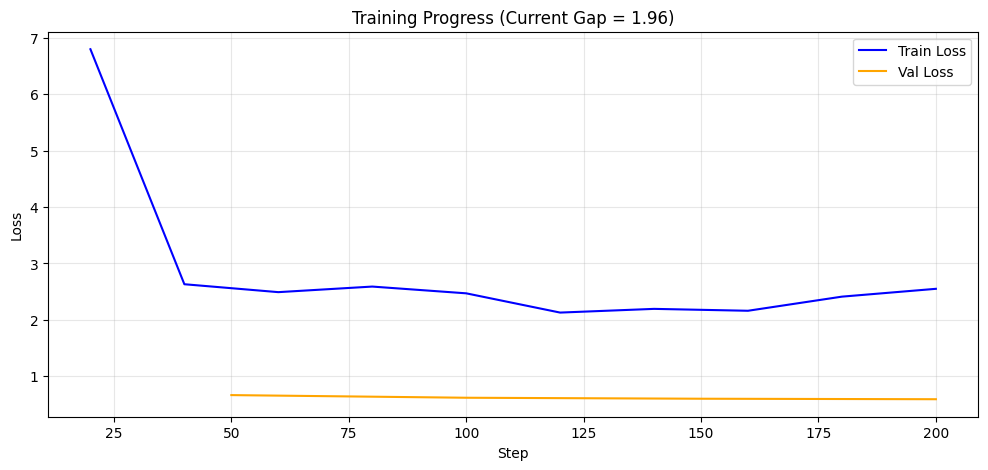

In [88]:
import matplotlib.pyplot as plt
if CFG.SFT:  #
    train_loss = trainHistoryDF[trainHistoryDF['loss'].notna()][['step', 'loss']]
    val_loss   = trainHistoryDF[trainHistoryDF['eval_loss'].notna()][['step', 'eval_loss']]

    plt.figure(figsize=(12, 5))
    plt.plot(train_loss['step'], train_loss['loss'], label='Train Loss', color='blue')
    plt.plot(val_loss['step'], val_loss['eval_loss'], label='Val Loss', color='orange')

    if len(val_loss) > 0:
        gap = train_loss['loss'].iloc[-1] - val_loss['eval_loss'].iloc[-1]
        plt.title(f"Training Progress (Current Gap = {gap:.2f})")
    else:
        plt.title("Training Progress")

    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [89]:
# Zip for SFT only
import shutil
if CFG.SFT:
    shutil.make_archive(CFG.OUTPUT_DIR +"/submission", "zip", SFT_ADAPTER)

    print("Done — submission.zip ready")

Done — submission.zip ready


In [90]:
clearMemory()

In [91]:
RUN_FINIAL_EVAL = False

In [92]:
# === Final Evaluation ===
if RUN_FINIAL_EVAL and CFG.SFT:
    print("Running final evaluation on SFT model...")
    # del model
    # del tokenizer
    # model, tokenizer = load_model(BASE_MODEL_PATH, SFT_ADAPTER)
    evaluate_model(
        model,
        tokenizer,
        val_size=20
    )

mlflow.end_run()

In [ ]:
loraEvalRet = mlflow.search_runs(search_all_experiments=True)
loraEvalRet

## Reinforcement Learning

In [ ]:
clearMemory()

In [ ]:
os.environ["UNSLOTH_VLLM_STANDBY"] = "1"   # ← Very important for memory saving in GRPO

In [ ]:
# === SAME STABLE PROMPT FORMAT AS SFT ===
def format_grpo_example(row):
    prompt = row['prompt']
    answer = str(row['answer']).strip()

    chat_prompt = f"""<|system|>You are an expert at discovering hidden transformation rules in Alice's Wonderland puzzles.
Analyze the examples carefully and determine the hidden rule.
**Output ONLY the final answer inside \\boxed{{}}.**
Do not explain your reasoning. Do not write any text before or after the boxed answer.
<|user|>{prompt}
<|assistant|>"""

    return {"prompt": chat_prompt, "ground_truth": answer}

In [ ]:

# def grpo_reward_function(prompts, completions, completion_ids=None, **kwargs):
#     """
#     Compatible with latest TRL GRPOTrainer
#     """
#     # ground_truths comes from the dataset column via **kwargs
#     ground_truths = kwargs.get("ground_truth", None)

#     if ground_truths is None:
#         # Fallback in case column name is different
#         ground_truths = kwargs.get("ground_truths", [""] * len(completions))

#     rewards = []
#     for completion, gt in zip(completions, ground_truths):
#         # Extract only the final answer
#         pred = completion.split("<|assistant|>")[-1].strip()

#         # Clean special tokens
#         for token in ["<|im_end|>", "<|endoftext|>", "</s>", "<|eot_id|>", "<|im_start|>"]:
#             pred = pred.replace(token, "").strip()

#         # Compare
#         reward = 1.0 if pred.lower().strip() == str(gt).lower().strip() else 0.0
#         rewards.append(reward)

#     return rewards

def grpo_reward_function(prompts, completions, completion_ids=None, **kwargs):
    """
    Reward function aligned with Kaggle evaluation metric.
    - Prioritizes \\boxed{} extraction
    - Supports exact match + relative numerical tolerance
    - Format reward for clean \boxed{} output
    """
    ground_truths = kwargs.get("ground_truth", [""] * len(completions))
    rewards = []

    for completion, gt in zip(completions, ground_truths):
        # Extract predicted answer (following Kaggle logic)
        pred = extract_answer(completion)

        # Format reward (encourage proper \boxed{} usage)
        format_reward = 0.0
        if "\\boxed{" in completion:
            format_reward += 0.35
        if len(pred) <= 20:                    # Not too long
            format_reward += 0.15

        # Correctness (exact or within tolerance)
        correct = is_correct(pred, gt, tolerance=0.01)
        correctness_reward = 1.0 if correct else 0.0

        # Partial similarity (for learning signal)
        similarity = difflib.SequenceMatcher(None, pred.lower(), gt.lower()).ratio()

        # Final reward
        reward = correctness_reward * 1.0 + similarity * 0.4 + format_reward
        rewards.append(max(0.0, min(2.0, reward)))

    return rewards

In [ ]:
del dataset
torch.cuda.empty_cache()
import gc
gc.collect()

In [ ]:
rfdataset = Dataset.from_pandas(trainDF).map(format_grpo_example, remove_columns=trainDF.columns.tolist())
rfdataset

In [ ]:
print(f"✅ GRPO dataset size: {len(rfdataset)} examples")

In [ ]:
# del model
# del tokenizer

In [ ]:
clearMemory()

In [ ]:
EXPERIMENT_NAME = "wonderland_nemotron_reasoning_grpo"

In [ ]:
# run = setup_mlflow_run(EXPERIMENT_NAME, "grpo_unsloth")
# === GRPO Training Arguments ===
if CFG.GRPO:
    run = setup_mlflow_run(EXPERIMENT_NAME, "grpo_training")
    mlflow.log_params({
        "max_lora_rank": 16,
        "max_tokens": 7680,
        "max_model_len": 8192,
        "temperature": 0.0,
        "top_p": 1.0,
    })


In [ ]:
if CFG.GRPO:
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=local_model_path,
        max_seq_length=4096,
        load_in_4bit=False,
        load_in_8bit=False,
        trust_remote_code=True,
    )

    # model = model.merge_and_unload()

    # # 4. Apply a FRESH clean LoRA (standard targets only — no expert targeting)
    # model = FastLanguageModel.get_peft_model(
    #     model,
    #     r=16,
    #     lora_alpha=32,
    #      target_modules = [
    #     "q_proj", "k_proj", "v_proj", "o_proj",
    #     "gate_proj", "up_proj", "down_proj",
    # ],
    #     lora_dropout=0.05,
    #     bias="none",
    #     use_gradient_checkpointing="unsloth",
    #     random_state=3407,
    # )

    peft_config = LoraConfig(
        r=16,
        lora_alpha=32,
        target_modules=[
            "q_proj", "k_proj", "v_proj", "o_proj",
            "gate_proj", "up_proj", "down_proj"
        ],
        lora_dropout=0.05,
        bias="none",
        task_type="CAUSAL_LM",
    )

    model = get_peft_model(model, peft_config)
    model = model.to(torch.bfloat16)

In [ ]:
TOTAL_STEPS = 80
SAVE_STEPS = TOTAL_STEPS * 4

In [ ]:
if CFG.GRPO:
    grpo_config = GRPOConfig(
        output_dir=CFG.OUTPUT_DIR,
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,
        learning_rate=5e-6,
        num_train_epochs=1,
        num_generations=2,           # Start with 2 (increase to 4 later if memory allows)
        max_steps = TOTAL_STEPS,
        save_steps = SAVE_STEPS,
        report_to = "mlflow", # Can use Weights & Biases
        beta=0.04,
        temperature=1.0,          # ← Must be > 0
        # do_sample=False,          # ← Add this
        top_p=1.0,
        logging_steps=20,
        save_strategy="no",          # avoid disk issues
        # bf16=True,
        gradient_checkpointing=True,
    )

In [ ]:
if CFG.GRPO:
    trainer = GRPOTrainer(
        model=model,
        args=grpo_config,
        train_dataset=rfdataset,
        processing_class=tokenizer,
        reward_funcs=grpo_reward_function,
    )


In [ ]:
if CFG.GRPO:
    print("🚀 Starting GRPO training with Unsloth...")
    trainer.train()

    print("💾 Saving final GRPO adapter...")
    trainer.save_model(OUTPUT_ADAPTER)
    print(f"✅ GRPO completed → {OUTPUT_ADAPTER}")

In [ ]:
if CFG.GRPO:
    trainHistoryDF = pd.DataFrame(trainer.state.log_history)
    trainHistoryDF

In [ ]:
import matplotlib.pyplot as plt
if CFG.GRPO:
    trainloss = trainHistoryDF[~trainHistoryDF["loss"].isnull()]
    # valloss = trainHistoryDF[~trainHistoryDF["eval_loss"].isnull()]
    plt.plot(trainloss["loss"], label="Train")
    # plt.plot(valloss["eval_loss"], label="Val")
    plt.title("LLM loss")
    plt.legend()
    plt.show()

In [ ]:
import shutil
if CFG.GRPO:
    shutil.make_archive("/kaggle/working/submission", "zip", OUTPUT_ADAPTER)

    print("Done — submission.zip ready")